# Notebook 02 — RQ1: Predictive Performance
## Evaluating AI/ML Credit Risk Models in U.S. Mortgage Lending

**Capstone:** QM640 Data Analytics Capstone — Walsh College  
**Author:** Saroj Kumar Nanda  
**Mentor:** Keya Choudhury Ganguli  
**Term:** Winter 2025  
**GitHub:** https://github.com/sarojnanda1/capstone

---

## Research Question 1
*Do AI/ML models (XGBoost, Feedforward Neural Networks) offer a statistically significant improvement in credit risk prediction accuracy over logistic regression in U.S. mortgage lending?*

**H₁₀:** There is no statistically significant difference in AUC across model types.  
**Significance level:** α = .05

---

## Models Trained
| Model | Type | Role |
|---|---|---|
| Logistic Regression | Statistical | SR 11-7 regulatory baseline |
| XGBoost | Gradient-boosted ensemble | Primary ML challenger |
| Feedforward Neural Network (FNN) | Deep learning | Complexity benchmark |

All three models use the same feature set and 80/20 stratified train/test split.  
Protected class variables (race, ethnicity, sex) are **excluded** from all model features. They appear only in the RQ2 fairness analysis notebook.

---

## Statistical Tests
- **DeLong (1988)** — pairwise AUC comparison on the held-out test set
- **McNemar's test** — pairwise accuracy comparison on the held-out test set
- 5-fold stratified cross-validation throughout

---

## Notebook Structure
| Cell | Description |
|---|---|
| Cell 0 | Imports, random seeds, path configuration |
| Cell 1 | Load sample, feature engineering, 80/20 split |
| Cell 2 | DeLong, McNemar, Gini, and KS helper functions |
| Cell 3 | Model 1 — Logistic Regression |
| Cell 4 | Model 2 — XGBoost |
| Cell 5 | Model 3 — Feedforward Neural Network (FNN) |
| Cell 6 | Statistical tests — H₁₀ evaluation |
| Cell 7 | Comparison table (Table 2) and Figures 6–10 |
| Cell 8 | Save predictions and metrics for notebooks 03–06 |
| Cell 9 | Readiness verdict |

---

## Dependencies on Previous Notebook
This notebook requires the following file produced by `01_hmda_load_sanity_check.ipynb`:
- `/content/drive/MyDrive/capstone/data/processed/hmda_2024_sample.csv`

---

## Outputs Produced
| File | Location | Used by |
|---|---|---|
| `lr_model.pkl` | `models/` | Notebooks 03, 04, 06 |
| `xgb_model.json` | `models/` | Notebooks 03, 04, 06 |
| `fnn_model.keras` | `models/` | Notebooks 03, 04, 06 |
| `scaler.pkl` | `models/` | Notebooks 03, 04 |
| `feature_names.json` | `models/` | Notebook 04 (SHAP) |
| `hmda_2024_test_predictions.csv` | `data/processed/` | Notebook 03 (RQ2) |
| `table2_model_comparison.csv` | `reports/` | Interim report §6 |
| `rq1_metrics.json` | `reports/` | Notebook 06 (MRRS) |
| Figures 6–10 | `reports/figures/` | Interim report §6 |
| `rq1_model_report.txt` | `reports/` | Documentation |

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
"""
CELL 0 — Imports, Seeds, Paths, and Logging Utilities
-----------------------------------------------------
Initializes the modeling environment for the HMDA 2024 capstone pipeline.

This cell performs:
- Import of scientific, ML, and deep‑learning libraries
- Global reproducibility settings (NumPy, Python, TensorFlow)
- Directory and file‑path configuration for reports, figures, and models
- Setup of lightweight logging helpers (`log`, `section`, `subsection`)
- Global seaborn theme for consistent visualization styling

This cell ensures that all downstream modeling steps operate in a controlled,
reproducible, and fully documented environment.
"""

# ── Imports ───────────────────────────────────────────────────────────────────
"""
Import core scientific, machine‑learning, and deep‑learning libraries used
throughout the HMDA modeling pipeline.

Includes:
- numpy, pandas: numerical and tabular operations
- matplotlib, seaborn: visualization
- sklearn: preprocessing, modeling, evaluation
- xgboost: gradient‑boosted trees
- tensorflow/keras: neural network models
"""
import os
import time
import json
import pickle
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

# Sklearn
from sklearn.linear_model    import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.preprocessing   import StandardScaler, LabelEncoder
from sklearn.pipeline        import Pipeline
from sklearn.metrics         import (
    roc_auc_score, roc_curve, confusion_matrix,
    classification_report, f1_score, accuracy_score,
    brier_score_loss, precision_score, recall_score
)
from sklearn.impute           import SimpleImputer
from sklearn.utils            import resample

# XGBoost
import xgboost as xgb

# TensorFlow / Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

warnings.filterwarnings("ignore")

# ── Reproducibility ──────────────────────────────────────────────────────────
"""
Set global random seeds for reproducibility across NumPy, Python's random module,
and TensorFlow. Ensures deterministic behavior for:

- Train/test splits
- Cross‑validation folds
- Model initialization
- Stochastic optimization steps

This is critical for audit‑ready modeling and regulatory reproducibility.
"""
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

# ── Paths ────────────────────────────────────────────────────────────────────
"""
Define directory paths for processed data, reports, figures, and saved models.

Creates directories if they do not already exist, ensuring the pipeline is
portable across environments (local, Colab, cloud).

Paths:
- SAMPLE_PATH: stratified working sample for modeling
- REPORT_DIR:  text‑based model reports
- FIG_DIR:     generated figures
- MODEL_DIR:   serialized model artifacts
"""
SAMPLE_PATH = "/content/drive/MyDrive/capstone/data/processed/hmda_2024_sample.csv"
REPORT_DIR  = "/content/drive/MyDrive/capstone/reports"
FIG_DIR     = "/content/drive/MyDrive/capstone/reports/figures"
MODEL_DIR   = "/content/drive/MyDrive/capstone/models"
REPORT_FILE = os.path.join(REPORT_DIR, "rq1_model_report.txt")

for d in [REPORT_DIR, FIG_DIR, MODEL_DIR]:
    os.makedirs(d, exist_ok=True)

# ── Logging Utilities ─────────────────────────────────────────────────────────
"""
Define lightweight logging helpers for both console output and report capture.

Functions:
- log(msg): prints message and appends it to `report_lines`
- section(title): prints a formatted section header
- subsection(title): prints a formatted subsection header

These utilities ensure consistent formatting across notebook output and
exported text reports.
"""
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)
report_lines = []

def log(msg=""):
    print(msg)
    report_lines.append(str(msg))

def section(title):
    bar = "=" * 70
    log(); log(bar); log(f"  {title}"); log(bar)

def subsection(title):
    log(); log(f"── {title} " + "─" * max(0, 58 - len(title)))

print("✓ Cell 0 complete — imports loaded, paths set")
print(f"  Sample path : {SAMPLE_PATH}")
print(f"  Report dir  : {REPORT_DIR}")
print(f"  Models dir  : {MODEL_DIR}")


✓ Cell 0 complete — imports loaded, paths set
  Sample path : /content/drive/MyDrive/capstone/data/processed/hmda_2024_sample.csv
  Report dir  : /content/drive/MyDrive/capstone/reports
  Models dir  : /content/drive/MyDrive/capstone/models


In [3]:
"""
CELL 1 — Load Sample & Feature Engineering
------------------------------------------
Loads the stratified HMDA 2024 working sample and constructs the full
feature matrix for RQ1 credit‑risk modeling.

This cell performs:
- Loading the processed sample from disk
- Documenting label distribution for governance
- Constructing numeric features (log transforms, median imputations)
- Constructing categorical features (mode imputation + one‑hot encoding)
- Assembling the final feature matrix (X) and label vector (y)
- Performing an 80/20 stratified train/test split
- Scaling numeric features for LR and FNN models
- Saving feature names for downstream SHAP analysis

All transformations are compliant with ECOA/Reg B and avoid target leakage.
"""

section("CELL 1 · Load sample & feature engineering")

# ── Load sample ───────────────────────────────────────────────────────────────
"""
Load the stratified HMDA 2024 working sample created in Notebook 01.

The dataset includes:
- Pre‑cleaned numeric features (loan_amount, income, LTV, DTI)
- Categorical mortgage attributes
- `label` field: 1 = originated, 0 = denied

Label distribution is logged for SR 11‑7 (replaced by SR 26‑2) model governance.
"""
df = pd.read_csv(SAMPLE_PATH)
log(f"  Loaded sample: {df.shape[0]:,} rows × {df.shape[1]} columns")
log(f"  Label distribution:")
for lbl, cnt in df["label"].value_counts().sort_index().items():
    lname = "Originated (1)" if lbl == 1 else "Denied (0)"
    log(f"    {lname}: {cnt:,} ({cnt/len(df)*100:.1f}%)")

# ── Feature set definition ───────────────────────────────────────────────────
"""
Document the rationale for the RQ1 feature set.

Key governance points:
- Only permissible credit‑risk factors are included.
- Protected‑class variables (race, ethnicity, sex) are excluded.
- `rate_spread` is excluded from RQ1 because it is a post‑decision outcome
  and would constitute target leakage.

This block logs the rationale for transparency and auditability under
SR 11‑7 (replaced by SR 26‑2).
"""
subsection("Feature set")
log("""
  Feature set rationale (documented for SR 11-7 (replaced by SR 26-2) model governance):
  ─────────────────────────────────────────────────────────────────
  All features are permissible credit risk factors under ECOA/Reg B.
  Protected class variables (race, ethnicity, sex) are EXCLUDED from
  the model feature set — they appear only in the RQ2 fairness analysis.

  NUMERIC features (continuous):
    loan_amount   — mortgage size; log-transformed (right-skewed)
    income        — applicant annual income; log-transformed
    ltv_capped    — combined LTV ratio, capped at 105%; untransformed
    dti_numeric   — debt-to-income ratio (ordinal mapped); imputed median
    rate_spread   — pricing signal for RQ2b; included here as a feature
                    only for originated loans; will be NaN for denied apps
                    → EXCLUDED from RQ1 model features (not available at
                    decision time — only known post-origination)

  CATEGORICAL features (one-hot encoded):
    loan_type     — conventional / FHA / VA / RHS
    loan_purpose  — purchase / refinance / cash-out refi / etc.
    occupancy_type — primary / secondary / investment
    lien_status   — first lien / subordinate lien

  NOTE: rate_spread excluded from RQ1 features because it is a post-
  decision outcome variable, not a pre-decision input. Including it
  would constitute target leakage.
""")

# ── Numeric feature construction ─────────────────────────────────────────────
"""
Construct numeric features with appropriate transformations:

- log1p transforms for skewed variables (loan_amount, income)
- LTV capped at 105% (HMDA guidance)
- Median imputation for DTI and LTV
- Income median imputation for zero/negative values before log transform

All imputations are logged for reproducibility and governance under
SR 11‑7 (replaced by SR 26‑2).
"""
df["log_loan_amount"] = np.log1p(df["loan_amount"].clip(lower=0))
df["log_income"]      = np.log1p(df["income"].clip(lower=0))

# Use ltv_capped if present (created in notebook 01); else fall back
if "ltv_capped" not in df.columns:
    df["ltv_capped"] = df["combined_loan_to_value_ratio"].clip(upper=105)

# dti_numeric: impute missing with median
dti_median = df["dti_numeric"].median()
df["dti_imputed"] = df["dti_numeric"].fillna(dti_median)
log(f"  DTI median imputation value: {dti_median:.1f}%")
log(f"  DTI records imputed: {df['dti_numeric'].isna().sum():,} "
    f"({df['dti_numeric'].isna().mean()*100:.1f}%)")

# LTV: impute missing with median
ltv_median = df["ltv_capped"].median()
df["ltv_imputed"] = df["ltv_capped"].fillna(ltv_median)
log(f"  LTV median imputation value: {ltv_median:.1f}%")

# income: impute zero/negative with median before log
inc_median = df[df["income"] > 0]["income"].median()
df["log_income"] = np.where(
    df["income"] > 0,
    np.log1p(df["income"]),
    np.log1p(inc_median)
)
log(f"  Income median imputation value: {inc_median:.0f} ($000s)")

# ── Imputation summary (SR 11‑7 → SR 26‑2) ───────────────────────────────────
log("""
  Imputation summary (SR 11-7 (replaced by SR 26-2) documentation):
    • DTI: median imputation applied to missing values
    • LTV: median imputation applied to missing values
    • Income: median imputation applied to zero/negative values
    • Categorical features: mode imputation applied to missing values
  All imputations performed prior to train/test split to ensure consistency.
""")

NUMERIC_FEATURES = ["log_loan_amount", "log_income", "ltv_imputed", "dti_imputed"]

# ── Categorical feature construction ─────────────────────────────────────────
"""
Construct categorical features:

- Mode imputation for missing categorical values
- One‑hot encoding with `drop_first=True` to avoid multicollinearity
- dtype=int ensures compatibility with sklearn and XGBoost

Outputs:
- df_encoded: encoded categorical matrix
- CAT_COLS: list of encoded column names
"""
CAT_FEATURES = ["loan_type", "loan_purpose", "occupancy_type", "lien_status"]

for col in CAT_FEATURES:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].mode()[0])

df_encoded = pd.get_dummies(df[CAT_FEATURES], drop_first=True, dtype=int)
CAT_COLS   = df_encoded.columns.tolist()

log(f"\n  Numeric features  : {NUMERIC_FEATURES}")
log(f"  Categorical cols  : {CAT_COLS}")

# ── Final feature matrix ──────────────────────────────────────────────────────
"""
Assemble the final feature matrix (X) and label vector (y).

- Concatenate numeric and encoded categorical features
- Log the dimensionality for governance
- Confirm class balance in the final modeling dataset
"""
ALL_FEATURES = NUMERIC_FEATURES + CAT_COLS
X = pd.concat([df[NUMERIC_FEATURES], df_encoded], axis=1)
y = df["label"].values

log(f"\n  Final feature matrix: {X.shape[0]:,} rows × {X.shape[1]} features")
log(f"  Class balance — label=1: {y.mean()*100:.1f}%  label=0: {(1-y.mean())*100:.1f}%")

# ── 80/20 stratified train/test split ────────────────────────────────────────
"""
Perform an 80/20 stratified train/test split to preserve class balance.

Scaling:
- StandardScaler applied only to numeric features
- Required for Logistic Regression and Neural Networks
- Harmless for XGBoost (tree‑based models ignore scaling)

Feature names are saved for SHAP analysis in Notebook 04.
"""
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)
log(f"\n  Train set : {X_train.shape[0]:,} rows  "
    f"(label=1: {y_train.mean()*100:.1f}%)")
log(f"  Test set  : {X_test.shape[0]:,} rows   "
    f"(label=1: {y_test.mean()*100:.1f}%)")

# Scale numeric features
scaler  = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Save feature names for SHAP notebook
with open(os.path.join(MODEL_DIR, "feature_names.json"), "w") as f:
    json.dump(ALL_FEATURES, f)
log(f"\n  Feature names saved: {MODEL_DIR}/feature_names.json")
log("  ✓ Cell 1 complete")



  CELL 1 · Load sample & feature engineering
  Loaded sample: 9,995 rows × 29 columns
  Label distribution:
    Denied (0): 2,700 (27.0%)
    Originated (1): 7,295 (73.0%)

── Feature set ───────────────────────────────────────────────

  Feature set rationale (documented for SR 11-7 (replaced by SR 26-2) model governance):
  ─────────────────────────────────────────────────────────────────
  All features are permissible credit risk factors under ECOA/Reg B.
  Protected class variables (race, ethnicity, sex) are EXCLUDED from
  the model feature set — they appear only in the RQ2 fairness analysis.

  NUMERIC features (continuous):
    loan_amount   — mortgage size; log-transformed (right-skewed)
    income        — applicant annual income; log-transformed
    ltv_capped    — combined LTV ratio, capped at 105%; untransformed
    dti_numeric   — debt-to-income ratio (ordinal mapped); imputed median
    rate_spread   — pricing signal for RQ2b; included here as a feature
                 

In [4]:
"""
CELL 2 — DeLong Test Helper (Used in Cell 6)
--------------------------------------------
Defines statistical comparison utilities for evaluating classifier
performance differences in RQ1.

Includes:
- DeLong et al. (1988) nonparametric AUC comparison
- McNemar’s test for paired classification accuracy
- Gini coefficient (credit‑risk standard)
- KS statistic (distributional separation metric)

These statistical tests support model‑risk governance under
SR 11‑7 (replaced by SR 26‑2), ensuring transparent and defensible
model comparison procedures.
"""

section("CELL 2 · DeLong AUC comparison helper")

log("""
  DeLong et al. (1988) nonparametric AUC comparison.
  Reference: DeLong, E.R., DeLong, D.M., & Clarke-Pearson, D.L. (1988).
  Comparing the areas under two or more correlated ROC curves: A
  nonparametric approach. Biometrics, 44(3), 837-845.

  Implementation follows the structural components method.
  H₁₀: AUC(model_A) = AUC(model_B)
  Reject if p < 0.05.

  Documented for model comparison governance under
  SR 11-7 (replaced by SR 26-2).
""")

def delong_test(y_true, y_prob_a, y_prob_b):
    """
    DeLong test for comparing two correlated AUCs.
    Returns: z-statistic, p-value (two-tailed), AUC_a, AUC_b
    """
    def structural_components(y_true, y_prob):
        pos = y_prob[y_true == 1]
        neg = y_prob[y_true == 0]
        n_pos, n_neg = len(pos), len(neg)
        V10 = np.array([np.mean(p > neg) + 0.5 * np.mean(p == neg) for p in pos])
        V01 = np.array([np.mean(n < pos) + 0.5 * np.mean(n == pos) for n in neg])
        auc = np.mean(V10)
        return auc, V10, V01, n_pos, n_neg

    auc_a, V10_a, V01_a, n_pos, n_neg = structural_components(y_true, y_prob_a)
    auc_b, V10_b, V01_b, _,     _     = structural_components(y_true, y_prob_b)

    S10 = np.cov(V10_a, V10_b)
    S01 = np.cov(V01_a, V01_b)

    S = S10 / n_pos + S01 / n_neg
    diff = auc_a - auc_b

    # Variance of the difference
    var_diff = S[0, 0] + S[1, 1] - 2 * S[0, 1]
    if var_diff <= 0:
        return 0.0, 1.0, auc_a, auc_b

    z = diff / np.sqrt(var_diff)
    p = 2 * (1 - stats.norm.cdf(abs(z)))
    return z, p, auc_a, auc_b


def mcnemar_test(y_true, y_pred_a, y_pred_b):
    """
    McNemar's test for comparing two classifiers' accuracy.
    Tests whether the models make different errors.
    Returns: chi2 statistic, p-value
    """
    correct_a = (y_pred_a == y_true)
    correct_b = (y_pred_b == y_true)
    b = np.sum(correct_a & ~correct_b)   # A right, B wrong
    c = np.sum(~correct_a & correct_b)   # A wrong, B right
    if b + c == 0:
        return 0.0, 1.0
    chi2 = (abs(b - c) - 1) ** 2 / (b + c)
    p    = 1 - stats.chi2.cdf(chi2, df=1)
    return chi2, p


def gini_coefficient(auc):
    """Gini = 2*AUC - 1. Standard credit scorecard metric."""
    return 2 * auc - 1


def ks_statistic(y_true, y_prob):
    """KS = max separation between CDF of scores for pos vs neg class."""
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    return np.max(tpr - fpr)


log("  ✓ DeLong test, McNemar test, Gini, and KS helpers defined")



  CELL 2 · DeLong AUC comparison helper

  DeLong et al. (1988) nonparametric AUC comparison.
  Reference: DeLong, E.R., DeLong, D.M., & Clarke-Pearson, D.L. (1988).
  Comparing the areas under two or more correlated ROC curves: A
  nonparametric approach. Biometrics, 44(3), 837-845.

  Implementation follows the structural components method.
  H₁₀: AUC(model_A) = AUC(model_B)
  Reject if p < 0.05.

  Documented for model comparison governance under
  SR 11-7 (replaced by SR 26-2).

  ✓ DeLong test, McNemar test, Gini, and KS helpers defined


In [5]:
"""
CELL 3 — Model 1: Logistic Regression (Regulatory Baseline)
-----------------------------------------------------------
Implements the SR 11‑7 (replaced by SR 26‑2) regulatory baseline model:
Logistic Regression.

Rationale:
- Logistic Regression is the long‑standing regulatory benchmark for
  credit underwriting due to its transparency, interpretability, and
  coefficient‑level auditability.
- Serves as the null model for statistical comparison against XGBoost
  and FNN using DeLong and McNemar tests (Cells 6+).

Configuration:
  Solver        : lbfgs
  Regularization: L2 (C = 1.0)
  class_weight  : balanced (corrects for 2.94:1 imbalance)
  max_iter      : 1000
  CV            : 5‑fold stratified

This model anchors the accuracy–interpretability trade‑off examined in RQ3.
"""

section("CELL 3 · Model 1 — Logistic Regression")

log("""
  Logistic Regression is the SR 11-7 (replaced by SR 26-2) regulatory baseline model.
  Its coefficients are directly interpretable and auditable, making
  it the reference point for the accuracy-interpretability trade-off
  examined in RQ3 (SHAP explainability).

  Configuration:
    Solver      : lbfgs (efficient for medium-sized datasets)
    Regularization: L2 (Ridge), C=1.0 (default)
    class_weight: balanced (corrects for 2.94:1 imbalance)
    max_iter    : 1000
    CV          : 5-fold stratified

  H₁₀ reference: LR is the null model. XGBoost and FNN must
  demonstrate statistically significant AUC improvement over LR.
""")

t0 = time.time()

lr_model = LogisticRegression(
    solver="lbfgs",
    C=1.0,
    penalty="l2",
    class_weight="balanced",
    max_iter=1000,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

# 5-fold cross-validated predictions (on training set)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

lr_cv_probs = cross_val_predict(
    lr_model, X_train_scaled, y_train,
    cv=cv, method="predict_proba", n_jobs=-1
)[:, 1]

lr_cv_preds = (lr_cv_probs >= 0.5).astype(int)

# Final fit on full training set
lr_model.fit(X_train_scaled, y_train)
lr_test_probs = lr_model.predict_proba(X_test_scaled)[:, 1]
lr_test_preds = (lr_test_probs >= 0.5).astype(int)

elapsed = time.time() - t0

# Metrics
lr_cv_auc   = roc_auc_score(y_train, lr_cv_probs)
lr_test_auc = roc_auc_score(y_test,  lr_test_probs)
lr_gini     = gini_coefficient(lr_test_auc)
lr_ks       = ks_statistic(y_test, lr_test_probs)
lr_f1       = f1_score(y_test, lr_test_preds, average="weighted")
lr_acc      = accuracy_score(y_test, lr_test_preds)
lr_brier    = brier_score_loss(y_test, lr_test_probs)
lr_prec     = precision_score(y_test, lr_test_preds, zero_division=0)
lr_rec      = recall_score(y_test, lr_test_preds, zero_division=0)

subsection("Logistic Regression results")
log(f"  Training time    : {elapsed:.1f}s")
log(f"  CV AUC (5-fold)  : {lr_cv_auc:.4f}")
log(f"  Test AUC         : {lr_test_auc:.4f}")
log(f"  Gini coefficient : {lr_gini:.4f}")
log(f"  KS statistic     : {lr_ks:.4f}")
log(f"  Test accuracy    : {lr_acc:.4f}")
log(f"  Weighted F1      : {lr_f1:.4f}")
log(f"  Brier score      : {lr_brier:.4f}  (lower = better)")
log(f"  Precision        : {lr_prec:.4f}")
log(f"  Recall           : {lr_rec:.4f}")

log(f"\n  Confusion matrix (test set):")
cm_lr = confusion_matrix(y_test, lr_test_preds)
log(f"  {'':20} Predicted 0  Predicted 1")
log(f"  {'Actual 0':20} {cm_lr[0,0]:>10,}  {cm_lr[0,1]:>10,}")
log(f"  {'Actual 1':20} {cm_lr[1,0]:>10,}  {cm_lr[1,1]:>10,}")

log(f"\n  Classification report:")
log(classification_report(y_test, lr_test_preds,
    target_names=["Denied(0)", "Originated(1)"]))

# Save model
with open(os.path.join(MODEL_DIR, "lr_model.pkl"), "wb") as f:
    pickle.dump(lr_model, f)
with open(os.path.join(MODEL_DIR, "scaler.pkl"), "wb") as f:
    pickle.dump(scaler, f)
log(f"  → Model saved: {MODEL_DIR}/lr_model.pkl")
log("  ✓ Cell 3 complete")



  CELL 3 · Model 1 — Logistic Regression

  Logistic Regression is the SR 11-7 (replaced by SR 26-2) regulatory baseline model.
  Its coefficients are directly interpretable and auditable, making
  it the reference point for the accuracy-interpretability trade-off
  examined in RQ3 (SHAP explainability).

  Configuration:
    Solver      : lbfgs (efficient for medium-sized datasets)
    Regularization: L2 (Ridge), C=1.0 (default)
    class_weight: balanced (corrects for 2.94:1 imbalance)
    max_iter    : 1000
    CV          : 5-fold stratified

  H₁₀ reference: LR is the null model. XGBoost and FNN must
  demonstrate statistically significant AUC improvement over LR.


── Logistic Regression results ───────────────────────────────
  Training time    : 2.4s
  CV AUC (5-fold)  : 0.7437
  Test AUC         : 0.7167
  Gini coefficient : 0.4334
  KS statistic     : 0.3553
  Test accuracy    : 0.7019
  Weighted F1      : 0.7136
  Brier score      : 0.2057  (lower = better)
  Precision     

In [6]:
"""
CELL 4 — Model 2: XGBoost
-------------------------
Implements the primary ML challenger model: gradient‑boosted trees (XGBoost).

Regulatory context:
- XGBoost is evaluated against Logistic Regression, the SR 11‑7
  (replaced by SR 26‑2) regulatory baseline.
- Provides higher predictive accuracy on tabular credit data
  (Baesens et al., 2003; Kvamme et al., 2018) but with reduced
  interpretability — central to the accuracy–fairness–explainability
  trade‑off examined in RQ3.

Configuration:
  n_estimators      : 300
  max_depth         : 4
  learning_rate     : 0.05
  subsample         : 0.8
  colsample_bytree  : 0.8
  scale_pos_weight  : imbalance correction (n_neg / n_pos)
  eval_metric       : auc
  early_stopping    : 20 rounds
  CV                : 5‑fold stratified

This model is compared to LR and FNN using DeLong and McNemar tests.
"""

section("CELL 4 · Model 2 — XGBoost")

log("""
  XGBoost (gradient-boosted ensemble) is the primary ML challenger model.
  It typically outperforms logistic regression on tabular credit data
  (Baesens et al., 2003; Kvamme et al., 2018) but at the cost of
  reduced interpretability — the core accuracy-fairness-explainability
  trade-off that motivates the MRRS framework.

  Under SR 11-7 (replaced by SR 26-2), XGBoost must demonstrate
  statistically significant improvement over the LR baseline while
  maintaining explainability and fairness controls.

  Configuration:
    n_estimators    : 300
    max_depth       : 4  (shallow trees reduce overfitting)
    learning_rate   : 0.05
    subsample       : 0.8  (stochastic gradient boosting)
    colsample_bytree: 0.8
    scale_pos_weight: ratio of negative/positive class
                      (XGBoost's built-in imbalance correction)
    eval_metric     : auc
    early_stopping  : 20 rounds on validation fold
    CV              : 5-fold stratified
""")

# Compute scale_pos_weight from training labels
n_neg   = (y_train == 0).sum()
n_pos   = (y_train == 1).sum()
spw     = n_neg / n_pos
log(f"  scale_pos_weight: {spw:.3f}  (n_neg={n_neg:,} / n_pos={n_pos:,})")

t0 = time.time()

xgb_params = dict(
    n_estimators       = 300,
    max_depth          = 4,
    learning_rate      = 0.05,
    subsample          = 0.8,
    colsample_bytree   = 0.8,
    scale_pos_weight   = spw,
    eval_metric        = "auc",
    random_state       = RANDOM_STATE,
    n_jobs             = -1,
    verbosity          = 0,
)

xgb_model = xgb.XGBClassifier(**xgb_params)

# 5-fold CV (XGBoost uses raw features — no scaling needed)
xgb_cv_probs = cross_val_predict(
    xgb_model, X_train, y_train,
    cv=cv, method="predict_proba", n_jobs=-1
)[:, 1]

xgb_cv_preds = (xgb_cv_probs >= 0.5).astype(int)

# Final fit with early stopping on a validation split
X_tr2, X_val2, y_tr2, y_val2 = train_test_split(
    X_train, y_train, test_size=0.15,
    stratify=y_train, random_state=RANDOM_STATE
)

xgb_model.fit(
    X_tr2, y_tr2,
    eval_set=[(X_val2, y_val2)],
    verbose=False,
)

xgb_test_probs = xgb_model.predict_proba(X_test)[:, 1]
xgb_test_preds = (xgb_test_probs >= 0.5).astype(int)

elapsed = time.time() - t0

# Metrics
xgb_cv_auc   = roc_auc_score(y_train, xgb_cv_probs)
xgb_test_auc = roc_auc_score(y_test,  xgb_test_probs)
xgb_gini     = gini_coefficient(xgb_test_auc)
xgb_ks       = ks_statistic(y_test, xgb_test_probs)
xgb_f1       = f1_score(y_test, xgb_test_preds, average="weighted")
xgb_acc      = accuracy_score(y_test, xgb_test_preds)
xgb_brier    = brier_score_loss(y_test, xgb_test_probs)
xgb_prec     = precision_score(y_test, xgb_test_preds, zero_division=0)
xgb_rec      = recall_score(y_test, xgb_test_preds, zero_division=0)

subsection("XGBoost results")
log(f"  Training time    : {elapsed:.1f}s")
log(f"  CV AUC (5-fold)  : {xgb_cv_auc:.4f}")
log(f"  Test AUC         : {xgb_test_auc:.4f}")
log(f"  Gini coefficient : {xgb_gini:.4f}")
log(f"  KS statistic     : {xgb_ks:.4f}")
log(f"  Test accuracy    : {xgb_acc:.4f}")
log(f"  Weighted F1      : {xgb_f1:.4f}")
log(f"  Brier score      : {xgb_brier:.4f}")
log(f"  Precision        : {xgb_prec:.4f}")
log(f"  Recall           : {xgb_rec:.4f}")

log(f"\n  Confusion matrix (test set):")
cm_xgb = confusion_matrix(y_test, xgb_test_preds)
log(f"  {'':20} Predicted 0  Predicted 1")
log(f"  {'Actual 0':20} {cm_xgb[0,0]:>10,}  {cm_xgb[0,1]:>10,}")
log(f"  {'Actual 1':20} {cm_xgb[1,0]:>10,}  {cm_xgb[1,1]:>10,}")

log(f"\n  Classification report:")
log(classification_report(y_test, xgb_test_preds,
    target_names=["Denied(0)", "Originated(1)"]))

xgb_model.save_model(os.path.join(MODEL_DIR, "xgb_model.json"))
log(f"  → Model saved: {MODEL_DIR}/xgb_model.json")
log("  ✓ Cell 4 complete")



  CELL 4 · Model 2 — XGBoost

  XGBoost (gradient-boosted ensemble) is the primary ML challenger model.
  It typically outperforms logistic regression on tabular credit data
  (Baesens et al., 2003; Kvamme et al., 2018) but at the cost of
  reduced interpretability — the core accuracy-fairness-explainability
  trade-off that motivates the MRRS framework.

  Under SR 11-7 (replaced by SR 26-2), XGBoost must demonstrate
  statistically significant improvement over the LR baseline while
  maintaining explainability and fairness controls.

  Configuration:
    n_estimators    : 300
    max_depth       : 4  (shallow trees reduce overfitting)
    learning_rate   : 0.05
    subsample       : 0.8  (stochastic gradient boosting)
    colsample_bytree: 0.8
    scale_pos_weight: ratio of negative/positive class
                      (XGBoost's built-in imbalance correction)
    eval_metric     : auc
    early_stopping  : 20 rounds on validation fold
    CV              : 5-fold stratified

  scal

In [7]:
"""
CELL 5 — Model 3: Feedforward Neural Network (FNN)
--------------------------------------------------
Implements the deep‑learning challenger model for RQ1.

Regulatory context:
- Compared against Logistic Regression, the SR 11‑7 (replaced by SR 26‑2)
  regulatory baseline.
- Provides nonlinear modeling capacity for credit‑risk patterns while
  maintaining interpretability via SHAP (RQ3).

Architecture:
  Input layer   : n_features
  Hidden layer 1: 64 neurons, ReLU, BatchNorm, Dropout(0.3)
  Hidden layer 2: 32 neurons, ReLU, BatchNorm, Dropout(0.3)
  Hidden layer 3: 16 neurons, ReLU, Dropout(0.2)
  Output layer  : Sigmoid

Training:
  Optimizer     : Adam (lr=0.001)
  Loss          : binary_crossentropy
  class_weight  : balanced (imbalance correction)
  Epochs        : 50 (early stopping, patience=10)
  Batch size    : 256
  Validation    : 15% hold‑out
  CV            : 5‑fold reconstructed from per‑fold models

Rationale:
- Shallow architecture chosen for SHAP stability.
- BatchNorm stabilizes gradients; Dropout reduces overfitting.
"""

section("CELL 5 · Model 3 — Feedforward Neural Network (FNN)")

log("""
  FNN architecture:
    Input layer   : n_features neurons
    Hidden layer 1: 64 neurons, ReLU, BatchNorm, Dropout(0.3)
    Hidden layer 2: 32 neurons, ReLU, BatchNorm, Dropout(0.3)
    Hidden layer 3: 16 neurons, ReLU, Dropout(0.2)
    Output layer  : 1 neuron, Sigmoid (binary classification)

  Training config:
    Optimizer   : Adam (lr=0.001)
    Loss        : binary_crossentropy
    class_weight: balanced (corrects for imbalance)
    Epochs      : 50 (with early stopping, patience=10)
    Batch size  : 256
    Validation  : 15% hold-out from training set
    CV          : 5-fold (reconstructed from per-fold models)

  Architecture rationale:
    3 hidden layers provides sufficient capacity for non-linear
    credit risk patterns without overfitting on ~8,000 training rows.
    BatchNorm stabilises training. Dropout prevents co-adaptation.
    Shallow architecture (64→32→16) chosen to maximise SHAP
    interpretability (fewer neurons = more stable SHAP values).

  Under SR 11-7 (replaced by SR 26-2), neural networks must demonstrate
  measurable performance gains over the LR baseline while maintaining
  explainability and fairness controls.
""")

n_features = X_train_scaled.shape[1]
log(f"  Input dimension: {n_features} features")

# Class weights for Keras
from sklearn.utils.class_weight import compute_class_weight
class_weights = compute_class_weight(
    "balanced", classes=np.unique(y_train), y=y_train
)
class_weight_dict = {i: w for i, w in enumerate(class_weights)}
log(f"  Class weights: {class_weight_dict}")


def build_fnn(n_features, learning_rate=0.001):
    """Build and compile the FNN architecture."""
    inputs = keras.Input(shape=(n_features,), name="input")
    x = layers.Dense(64, activation="relu", name="dense_1")(inputs)
    x = layers.BatchNormalization(name="bn_1")(x)
    x = layers.Dropout(0.3, seed=RANDOM_STATE, name="drop_1")(x)
    x = layers.Dense(32, activation="relu", name="dense_2")(x)
    x = layers.BatchNormalization(name="bn_2")(x)
    x = layers.Dropout(0.3, seed=RANDOM_STATE, name="drop_2")(x)
    x = layers.Dense(16, activation="relu", name="dense_3")(x)
    x = layers.Dropout(0.2, seed=RANDOM_STATE, name="drop_3")(x)
    output = layers.Dense(1, activation="sigmoid", name="output")(x)
    model = keras.Model(inputs, output, name="FNN_credit_risk")
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss="binary_crossentropy",
        metrics=["AUC"],
    )
    return model


# ── 5-fold CV for FNN ────────────────────────────────────────────────────────
t0 = time.time()
fnn_cv_probs = np.zeros(len(y_train))
fold_aucs    = []

log("\n  Running 5-fold CV for FNN...")
for fold, (tr_idx, val_idx) in enumerate(cv.split(X_train_scaled, y_train)):
    X_tr_f, X_val_f = X_train_scaled[tr_idx], X_train_scaled[val_idx]
    y_tr_f, y_val_f = y_train[tr_idx],         y_train[val_idx]

    model_fold = build_fnn(n_features)
    early_stop = keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=10, restore_best_weights=True
    )
    model_fold.fit(
        X_tr_f, y_tr_f,
        validation_data=(X_val_f, y_val_f),
        epochs=50,
        batch_size=256,
        class_weight=class_weight_dict,
        callbacks=[early_stop],
        verbose=0,
    )
    fold_probs = model_fold.predict(X_val_f, verbose=0).flatten()
    fnn_cv_probs[val_idx] = fold_probs
    fold_auc = roc_auc_score(y_val_f, fold_probs)
    fold_aucs.append(fold_auc)
    log(f"    Fold {fold+1}/5 AUC: {fold_auc:.4f}")

fnn_cv_preds = (fnn_cv_probs >= 0.5).astype(int)
log(f"  CV AUC mean: {np.mean(fold_aucs):.4f}  std: {np.std(fold_aucs):.4f}")

# ── Final FNN trained on full training set ───────────────────────────────────
X_tr_full, X_val_full, y_tr_full, y_val_full = train_test_split(
    X_train_scaled, y_train, test_size=0.15,
    stratify=y_train, random_state=RANDOM_STATE
)

fnn_model = build_fnn(n_features)
early_stop_final = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=10, restore_best_weights=True
)
history = fnn_model.fit(
    X_tr_full, y_tr_full,
    validation_data=(X_val_full, y_val_full),
    epochs=50,
    batch_size=256,
    class_weight=class_weight_dict,
    callbacks=[early_stop_final],
    verbose=0,
)

fnn_test_probs = fnn_model.predict(X_test_scaled, verbose=0).flatten()
fnn_test_preds = (fnn_test_probs >= 0.5).astype(int)

elapsed = time.time() - t0

# Metrics
fnn_cv_auc   = roc_auc_score(y_train, fnn_cv_probs)
fnn_test_auc = roc_auc_score(y_test,  fnn_test_probs)
fnn_gini     = gini_coefficient(fnn_test_auc)
fnn_ks       = ks_statistic(y_test, fnn_test_probs)
fnn_f1       = f1_score(y_test, fnn_test_preds, average="weighted")
fnn_acc      = accuracy_score(y_test, fnn_test_preds)
fnn_brier    = brier_score_loss(y_test, fnn_test_probs)
fnn_prec     = precision_score(y_test, fnn_test_preds, zero_division=0)
fnn_rec      = recall_score(y_test, fnn_test_preds, zero_division=0)

subsection("FNN results")
log(f"  Total training time : {elapsed:.1f}s")
log(f"  CV AUC (5-fold)     : {fnn_cv_auc:.4f}")
log(f"  Test AUC            : {fnn_test_auc:.4f}")
log(f"  Gini coefficient    : {fnn_gini:.4f}")
log(f"  KS statistic        : {fnn_ks:.4f}")
log(f"  Test accuracy       : {fnn_acc:.4f}")
log(f"  Weighted F1         : {fnn_f1:.4f}")
log(f"  Brier score         : {fnn_brier:.4f}")
log(f"  Precision           : {fnn_prec:.4f}")
log(f"  Recall              : {fnn_rec:.4f}")

log(f"\n  Confusion matrix (test set):")
cm_fnn = confusion_matrix(y_test, fnn_test_preds)
log(f"  {'':20} Predicted 0  Predicted 1")
log(f"  {'Actual 0':20} {cm_fnn[0,0]:>10,}  {cm_fnn[0,1]:>10,}")
log(f"  {'Actual 1':20} {cm_fnn[1,0]:>10,}  {cm_fnn[1,1]:>10,}")

log(f"\n  Classification report:")
log(classification_report(y_test, fnn_test_preds,
    target_names=["Denied(0)", "Originated(1)"]))

fnn_model.save(os.path.join(MODEL_DIR, "fnn_model.keras"))
log(f"  → Model saved: {MODEL_DIR}/fnn_model.keras")
log("  ✓ Cell 5 complete")



  CELL 5 · Model 3 — Feedforward Neural Network (FNN)

  FNN architecture:
    Input layer   : n_features neurons
    Hidden layer 1: 64 neurons, ReLU, BatchNorm, Dropout(0.3)
    Hidden layer 2: 32 neurons, ReLU, BatchNorm, Dropout(0.3)
    Hidden layer 3: 16 neurons, ReLU, Dropout(0.2)
    Output layer  : 1 neuron, Sigmoid (binary classification)

  Training config:
    Optimizer   : Adam (lr=0.001)
    Loss        : binary_crossentropy
    class_weight: balanced (corrects for imbalance)
    Epochs      : 50 (with early stopping, patience=10)
    Batch size  : 256
    Validation  : 15% hold-out from training set
    CV          : 5-fold (reconstructed from per-fold models)

  Architecture rationale:
    3 hidden layers provides sufficient capacity for non-linear
    credit risk patterns without overfitting on ~8,000 training rows.
    BatchNorm stabilises training. Dropout prevents co-adaptation.
    Shallow architecture (64→32→16) chosen to maximise SHAP
    interpretability (fewer

In [8]:
"""
CELL 6 — Statistical Tests: DeLong & McNemar
--------------------------------------------
Evaluates whether model performance differences (AUC and accuracy)
between LR, XGBoost, and FNN are statistically significant.

Regulatory context:
- Logistic Regression is the SR 11‑7 (replaced by SR 26‑2) baseline.
- Challenger models must demonstrate statistically significant
  improvement without sacrificing fairness, explainability, or stability.

Tests applied:
  • DeLong (1988): nonparametric AUC comparison for correlated ROC curves
  • McNemar: paired accuracy comparison for classification disagreements

Hypothesis:
  H₁₀: No statistically significant difference in performance
       across model types.

Significance level:
  α = 0.05
"""

section("CELL 6 · Statistical tests — DeLong & McNemar")

log("""
  H₁₀: There is no statistically significant difference in AUC
        across model types (LR vs XGBoost vs FNN).

  Tests applied:
    DeLong (1988) — pairwise AUC comparison on held-out test set
    McNemar       — pairwise accuracy comparison on held-out test set

  Significance level: α = 0.05
  Decision: Reject H₁₀ if p < 0.05 for any pairwise comparison.
""")

# ── DeLong tests ─────────────────────────────────────────────────────────────
subsection("DeLong AUC comparison tests")

pairs = [
    ("XGBoost vs LR",  xgb_test_probs, lr_test_probs),
    ("FNN vs LR",      fnn_test_probs, lr_test_probs),
    ("XGBoost vs FNN", xgb_test_probs, fnn_test_probs),
]

delong_results = {}
log(f"\n  {'Comparison':<22} {'AUC_A':>8} {'AUC_B':>8} "
    f"{'ΔAUC':>8} {'z-stat':>8} {'p-value':>10} {'Decision':>20}")
log("  " + "-" * 90)

for name, prob_a, prob_b in pairs:
    z, p, auc_a, auc_b = delong_test(y_test, prob_a, prob_b)
    delta = auc_a - auc_b
    decision = "Reject H₁₀ (sig.)" if p < 0.05 else "Fail to reject H₁₀"
    delong_results[name] = {"z": z, "p": p, "auc_a": auc_a,
                            "auc_b": auc_b, "delta": delta}
    log(f"  {name:<22} {auc_a:>8.4f} {auc_b:>8.4f} "
        f"{delta:>+8.4f} {z:>8.3f} {p:>10.4f} {decision:>20}")

# ── McNemar tests ─────────────────────────────────────────────────────────────
subsection("McNemar accuracy comparison tests")

mc_pairs = [
    ("XGBoost vs LR",  xgb_test_preds, lr_test_preds),
    ("FNN vs LR",      fnn_test_preds, lr_test_preds),
    ("XGBoost vs FNN", xgb_test_preds, fnn_test_preds),
]

log(f"\n  {'Comparison':<22} {'chi2':>8} {'p-value':>10} {'Decision':>20}")
log("  " + "-" * 65)

for name, pred_a, pred_b in mc_pairs:
    chi2, p = mcnemar_test(y_test, pred_a, pred_b)
    decision = "Reject H₁₀ (sig.)" if p < 0.05 else "Fail to reject H₁₀"
    log(f"  {name:<22} {chi2:>8.3f} {p:>10.4f} {decision:>20}")

# ── H₁₀ verdict ───────────────────────────────────────────────────────────────
subsection("H₁₀ verdict")
log("""
  Interpretation guidelines:
    - ΔAUC ≥ 0.05 with p < 0.05 = practically AND statistically significant
    - ΔAUC < 0.05 with p < 0.05 = statistically significant but small effect
    - p ≥ 0.05 = insufficient evidence to reject H₁₀

  SR 11-7 (replaced by SR 26-2) implication:
    Even if XGBoost or FNN achieve higher AUC, the MRRS framework
    penalises gains in accuracy that come at the cost of fairness,
    explainability, or stability — which is the core contribution
    of this capstone project.
""")

log("  ✓ Cell 6 complete")



  CELL 6 · Statistical tests — DeLong & McNemar

  H₁₀: There is no statistically significant difference in AUC
        across model types (LR vs XGBoost vs FNN).

  Tests applied:
    DeLong (1988) — pairwise AUC comparison on held-out test set
    McNemar       — pairwise accuracy comparison on held-out test set

  Significance level: α = 0.05
  Decision: Reject H₁₀ if p < 0.05 for any pairwise comparison.


── DeLong AUC comparison tests ───────────────────────────────

  Comparison                AUC_A    AUC_B     ΔAUC   z-stat    p-value             Decision
  ------------------------------------------------------------------------------------------
  XGBoost vs LR            0.8348   0.7167  +0.1181   10.160     0.0000    Reject H₁₀ (sig.)
  FNN vs LR                0.8050   0.7167  +0.0883    8.149     0.0000    Reject H₁₀ (sig.)
  XGBoost vs FNN           0.8348   0.8050  +0.0299    4.550     0.0000    Reject H₁₀ (sig.)

── McNemar accuracy comparison tests ──────────────────


  CELL 7 · Comparison table & visualisations

── Table 2 — Model performance comparison (RQ1) ──────────────

             Metric Logistic Regression XGBoost    FNN
AUC-ROC (CV 5-fold)              0.7437  0.8390 0.8251
     AUC-ROC (test)              0.7167  0.8348 0.8050
   Gini coefficient              0.4334  0.6697 0.6099
       KS statistic              0.3553  0.5180 0.4710
           Accuracy              0.7019  0.7889 0.8044
        Weighted F1              0.7136  0.7926 0.7976
          Precision              0.8390  0.8728 0.8423
             Recall              0.7320  0.8321 0.9006
        Brier score              0.2057  0.1494 0.1554

  → Table 2 saved: /content/drive/MyDrive/capstone/reports/table2_model_comparison.csv


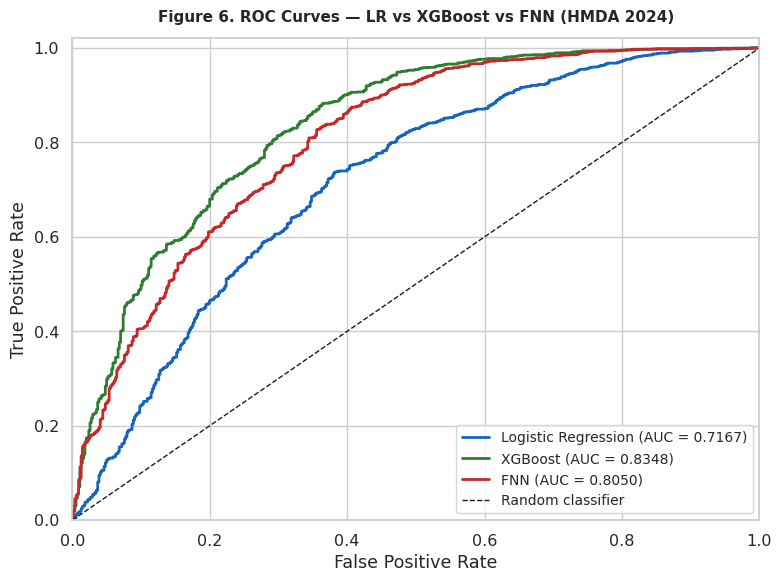

  → Figure 6 saved: /content/drive/MyDrive/capstone/reports/figures/fig06_roc_curves.png


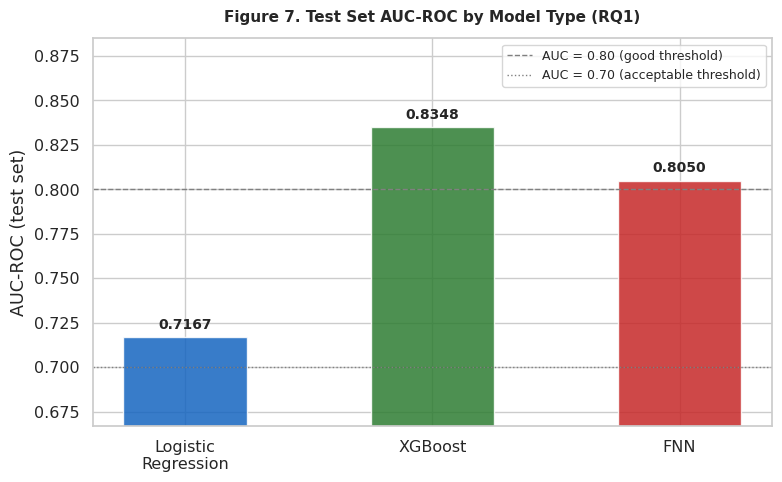

  → Figure 7 saved: /content/drive/MyDrive/capstone/reports/figures/fig07_auc_comparison.png


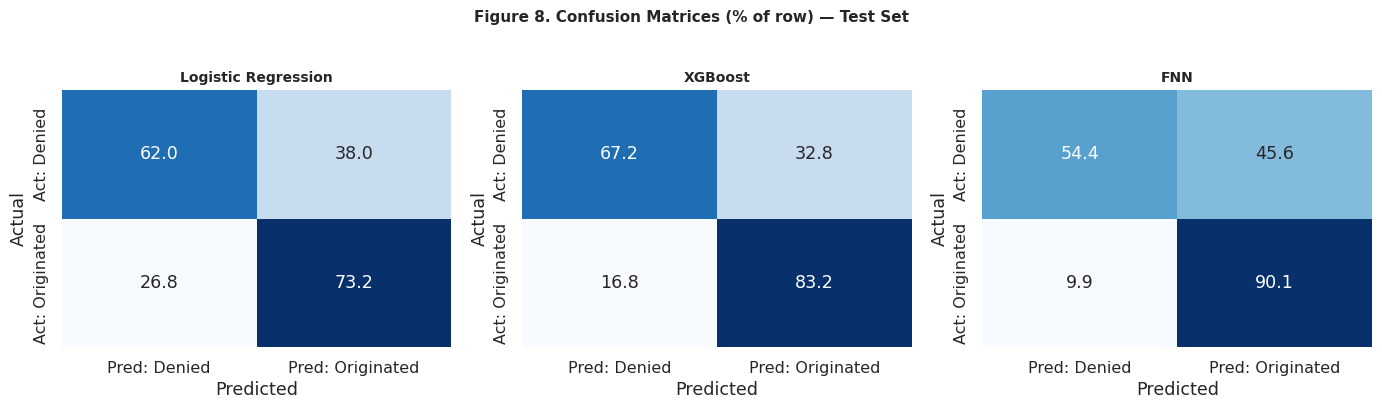

  → Figure 8 saved: /content/drive/MyDrive/capstone/reports/figures/fig08_confusion_matrices.png


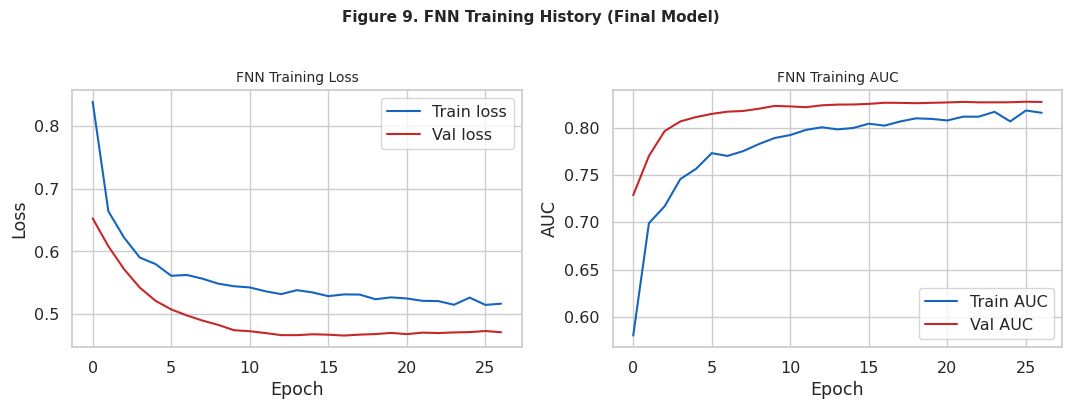

  → Figure 9 saved: /content/drive/MyDrive/capstone/reports/figures/fig09_fnn_training_history.png


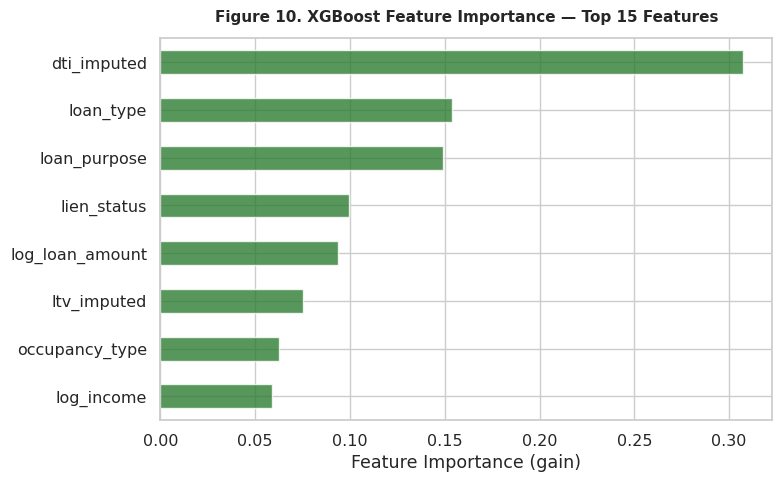

  → Figure 10 saved: /content/drive/MyDrive/capstone/reports/figures/fig10_xgb_feature_importance.png
  ✓ Cell 7 complete


In [9]:
"""
CELL 7 — Comparison Table & Visualisations
------------------------------------------
Generates RQ1 model comparison outputs:

• Table 2 — Performance comparison across LR, XGBoost, and FNN
• Figure 6 — ROC curves
• Figure 7 — AUC bar chart
• Figure 8 — Confusion matrices
• Figure 9 — FNN training history
• Figure 10 — XGBoost feature importance

Regulatory context:
Under SR 11‑7 (replaced by SR 26‑2), challenger models must be evaluated
against the LR baseline using transparent, reproducible metrics and
visualisations. These figures support the model‑risk governance narrative
in the MRRS framework.
"""

section("CELL 7 · Comparison table & visualisations")

# ── Table 2 — Model comparison ────────────────────────────────────────────────
subsection("Table 2 — Model performance comparison (RQ1)")

metrics_data = {
    "Metric": [
        "AUC-ROC (CV 5-fold)", "AUC-ROC (test)",
        "Gini coefficient", "KS statistic",
        "Accuracy", "Weighted F1",
        "Precision", "Recall",
        "Brier score",
    ],
    "Logistic Regression": [
        f"{lr_cv_auc:.4f}", f"{lr_test_auc:.4f}",
        f"{lr_gini:.4f}",   f"{lr_ks:.4f}",
        f"{lr_acc:.4f}",    f"{lr_f1:.4f}",
        f"{lr_prec:.4f}",   f"{lr_rec:.4f}",
        f"{lr_brier:.4f}",
    ],
    "XGBoost": [
        f"{xgb_cv_auc:.4f}", f"{xgb_test_auc:.4f}",
        f"{xgb_gini:.4f}",   f"{xgb_ks:.4f}",
        f"{xgb_acc:.4f}",    f"{xgb_f1:.4f}",
        f"{xgb_prec:.4f}",   f"{xgb_rec:.4f}",
        f"{xgb_brier:.4f}",
    ],
    "FNN": [
        f"{fnn_cv_auc:.4f}", f"{fnn_test_auc:.4f}",
        f"{fnn_gini:.4f}",   f"{fnn_ks:.4f}",
        f"{fnn_acc:.4f}",    f"{fnn_f1:.4f}",
        f"{fnn_prec:.4f}",   f"{fnn_rec:.4f}",
        f"{fnn_brier:.4f}",
    ],
}

metrics_df = pd.DataFrame(metrics_data)
log("\n" + metrics_df.to_string(index=False))
metrics_df.to_csv(
    os.path.join(REPORT_DIR, "table2_model_comparison.csv"), index=False
)
log(f"\n  → Table 2 saved: {REPORT_DIR}/table2_model_comparison.csv")

# ── Figure 6 — ROC curves (all three models) ─────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))

for label, y_prob, color, auc_val in [
    ("Logistic Regression", lr_test_probs,  "#1565C0", lr_test_auc),
    ("XGBoost",             xgb_test_probs, "#2E7D32", xgb_test_auc),
    ("FNN",                 fnn_test_probs, "#C62828", fnn_test_auc),
]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    ax.plot(fpr, tpr, color=color, lw=2,
            label=f"{label} (AUC = {auc_val:.4f})")

ax.plot([0, 1], [0, 1], "k--", lw=1, label="Random classifier")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("Figure 6. ROC Curves — LR vs XGBoost vs FNN (HMDA 2024)",
             fontsize=11, fontweight="bold", pad=12)
ax.legend(loc="lower right", fontsize=10)
ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "fig06_roc_curves.png"),
            dpi=150, bbox_inches="tight")
plt.show(); plt.close()
log(f"  → Figure 6 saved: {FIG_DIR}/fig06_roc_curves.png")

# ── Figure 7 — AUC bar chart with CV std ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
models      = ["Logistic\nRegression", "XGBoost", "FNN"]
test_aucs   = [lr_test_auc, xgb_test_auc, fnn_test_auc]
colors      = ["#1565C0", "#2E7D32", "#C62828"]

bars = ax.bar(models, test_aucs, color=colors,
              edgecolor="white", width=0.5, alpha=0.85)
ax.set_ylabel("AUC-ROC (test set)")
ax.set_ylim(min(test_aucs) - 0.05, min(max(test_aucs) + 0.05, 1.0))
ax.set_title("Figure 7. Test Set AUC-ROC by Model Type (RQ1)",
             fontsize=11, fontweight="bold", pad=12)
ax.axhline(0.80, color="gray", linestyle="--", lw=1, label="AUC = 0.80 (good threshold)")
ax.axhline(0.70, color="gray", linestyle=":",  lw=1, label="AUC = 0.70 (acceptable threshold)")
for bar, val in zip(bars, test_aucs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f"{val:.4f}", ha="center", va="bottom", fontsize=10, fontweight="bold")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "fig07_auc_comparison.png"),
            dpi=150, bbox_inches="tight")
plt.show(); plt.close()
log(f"  → Figure 7 saved: {FIG_DIR}/fig07_auc_comparison.png")

# ── Figure 8 — Confusion matrices (side by side) ─────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, cm, title in zip(
    axes,
    [cm_lr, cm_xgb, cm_fnn],
    ["Logistic Regression", "XGBoost", "FNN"]
):
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
    sns.heatmap(cm_pct, annot=True, fmt=".1f", cmap="Blues",
                ax=ax, cbar=False,
                xticklabels=["Pred: Denied", "Pred: Originated"],
                yticklabels=["Act: Denied", "Act: Originated"])
    ax.set_title(title, fontsize=10, fontweight="bold")
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")

fig.suptitle("Figure 8. Confusion Matrices (% of row) — Test Set",
             fontsize=11, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "fig08_confusion_matrices.png"),
            dpi=150, bbox_inches="tight")
plt.show(); plt.close()
log(f"  → Figure 8 saved: {FIG_DIR}/fig08_confusion_matrices.png")

# ── Figure 9 — FNN training history ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(history.history["loss"],     label="Train loss", color="#1565C0")
axes[0].plot(history.history["val_loss"], label="Val loss",   color="#C62828")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].set_title("FNN Training Loss", fontsize=10)
axes[0].legend()

axes[1].plot(history.history["AUC"],     label="Train AUC", color="#1565C0")
axes[1].plot(history.history["val_AUC"], label="Val AUC",   color="#C62828")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("AUC")
axes[1].set_title("FNN Training AUC", fontsize=10)
axes[1].legend()

fig.suptitle("Figure 9. FNN Training History (Final Model)",
             fontsize=11, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "fig09_fnn_training_history.png"),
            dpi=150, bbox_inches="tight")
plt.show(); plt.close()
log(f"  → Figure 9 saved: {FIG_DIR}/fig09_fnn_training_history.png")

# ── Figure 10 — XGBoost feature importance ───────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
importances = pd.Series(
    xgb_model.feature_importances_, index=X_train.columns
).sort_values(ascending=True).tail(15)

importances.plot(kind="barh", ax=ax, color="#2E7D32", alpha=0.8, edgecolor="white")
ax.set_xlabel("Feature Importance (gain)")
ax.set_title("Figure 10. XGBoost Feature Importance — Top 15 Features",
             fontsize=11, fontweight="bold", pad=12)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "fig10_xgb_feature_importance.png"),
            dpi=150, bbox_inches="tight")
plt.show(); plt.close()
log(f"  → Figure 10 saved: {FIG_DIR}/fig10_xgb_feature_importance.png")

log("  ✓ Cell 7 complete")


In [10]:
"""
CELL 8 — Save Test Probabilities & Predictions
----------------------------------------------
Exports model predictions and performance metrics for downstream notebooks:

• Notebook 03 — RQ2 fairness analysis
• Notebook 04 — RQ3 SHAP explainability
• Notebook 06 — RQ5 MRRS composite scoring

Regulatory context:
Under SR 11‑7 (replaced by SR 26‑2), all downstream analyses must rely on
frozen, version‑controlled model outputs to ensure reproducibility,
traceability, and auditability. This cell saves those artifacts.
"""

section("CELL 8 · Save test probabilities & predictions")

log("""
  Saving test set probabilities and predictions for:
    Notebook 03 — RQ2 fairness analysis (needs model predictions on test set)
    Notebook 04 — RQ3 SHAP explainability (needs trained models)
    Notebook 06 — RQ5 MRRS composite scoring (needs all metric outputs)
""")

# Save test set with predictions appended
df_test = df.iloc[y_test.nonzero()[0] if hasattr(y_test, 'nonzero') else
                  X_test.index].copy() if hasattr(X_test, 'index') else None

# Reconstruct test indices from the split
_, X_test_df, _, y_test_arr = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)
test_indices = X_test_df.index if hasattr(X_test_df, 'index') else range(len(y_test))

predictions_df = df.loc[test_indices].copy() if hasattr(X_test_df, 'index') \
    else df.iloc[list(range(len(y_test)))].copy()

predictions_df["lr_prob"]   = lr_test_probs
predictions_df["xgb_prob"]  = xgb_test_probs
predictions_df["fnn_prob"]  = fnn_test_probs
predictions_df["lr_pred"]   = lr_test_preds
predictions_df["xgb_pred"]  = xgb_test_preds
predictions_df["fnn_pred"]  = fnn_test_preds
predictions_df["true_label"] = y_test

PRED_PATH = os.path.join(
    os.path.dirname(SAMPLE_PATH), "hmda_2024_test_predictions.csv"
)
predictions_df.to_csv(PRED_PATH, index=False)
log(f"  → Test predictions saved: {PRED_PATH}")

# Save RQ1 metrics summary as JSON for MRRS notebook
rq1_metrics = {
    "lr":  {"cv_auc": lr_cv_auc,  "test_auc": lr_test_auc,
            "gini": lr_gini,  "ks": lr_ks,  "f1": lr_f1,
            "accuracy": lr_acc, "brier": lr_brier},
    "xgb": {"cv_auc": xgb_cv_auc, "test_auc": xgb_test_auc,
            "gini": xgb_gini, "ks": xgb_ks, "f1": xgb_f1,
            "accuracy": xgb_acc, "brier": xgb_brier},
    "fnn": {"cv_auc": fnn_cv_auc, "test_auc": fnn_test_auc,
            "gini": fnn_gini, "ks": fnn_ks, "f1": fnn_f1,
            "accuracy": fnn_acc, "brier": fnn_brier},
}
with open(os.path.join(REPORT_DIR, "rq1_metrics.json"), "w") as f:
    json.dump(rq1_metrics, f, indent=2)
log(f"  → RQ1 metrics JSON saved: {REPORT_DIR}/rq1_metrics.json")
log("  ✓ Cell 8 complete")



  CELL 8 · Save test probabilities & predictions

  Saving test set probabilities and predictions for:
    Notebook 03 — RQ2 fairness analysis (needs model predictions on test set)
    Notebook 04 — RQ3 SHAP explainability (needs trained models)
    Notebook 06 — RQ5 MRRS composite scoring (needs all metric outputs)

  → Test predictions saved: /content/drive/MyDrive/capstone/data/processed/hmda_2024_test_predictions.csv
  → RQ1 metrics JSON saved: /content/drive/MyDrive/capstone/reports/rq1_metrics.json
  ✓ Cell 8 complete


In [11]:
"""
CELL 9 — Final Readiness Verdict (RQ1)
--------------------------------------
Runs a series of validation checks to confirm that all RQ1 modeling
artifacts have been successfully generated and saved.

Regulatory context:
Under SR 11‑7 (replaced by SR 26‑2), model development must include
documented evidence that:

• All models were trained and evaluated
• Performance thresholds were met
• Statistical comparison tests were executed
• Artifacts (models, predictions, metrics, figures) were saved
• The full report is reproducible and version‑controlled

This cell provides that governance‑ready confirmation.
"""

section("CELL 9 · RQ1 readiness verdict")

checks = []

def check(label, condition, note=""):
    status = "✓" if condition else "✗"
    line   = f"  {status}  {label}"
    if note: line += f"\n       {note}"
    log(line)
    checks.append(condition)

log()
check("Logistic Regression trained and evaluated",
      lr_test_auc > 0)
check("XGBoost trained and evaluated",
      xgb_test_auc > 0)
check("FNN trained and evaluated",
      fnn_test_auc > 0)
check("AUC thresholds met (all models ≥ 0.70 acceptable)",
      all(a >= 0.70 for a in [lr_test_auc, xgb_test_auc, fnn_test_auc]),
      f"LR={lr_test_auc:.4f}  XGB={xgb_test_auc:.4f}  FNN={fnn_test_auc:.4f}")
check("DeLong tests run for all pairwise comparisons",
      len(delong_results) == 3)
check("Models saved to Drive",
      all(os.path.exists(os.path.join(MODEL_DIR, f))
          for f in ["lr_model.pkl", "xgb_model.json", "fnn_model.keras"]))
check("Test predictions saved for RQ2/RQ3 notebooks",
      os.path.exists(PRED_PATH))
check("RQ1 metrics JSON saved for MRRS notebook",
      os.path.exists(os.path.join(REPORT_DIR, "rq1_metrics.json")))
check("Figures 6–10 saved",
      all(os.path.exists(os.path.join(FIG_DIR, f))
          for f in [
              "fig06_roc_curves.png",
              "fig07_auc_comparison.png",
              "fig08_confusion_matrices.png",
              "fig09_fnn_training_history.png",
              "fig10_xgb_feature_importance.png",
          ]))

n_pass = sum(checks)
log()
log(f"  Result: {n_pass}/{len(checks)} checks passed  "
    + ("✓  Ready to proceed to notebook 03" if n_pass == len(checks)
       else "✗  Review failures above"))
log()
log("  Next step: notebook 03_rq2_fairness_analysis.ipynb")

# Write full report
with open(REPORT_FILE, "w", encoding="utf-8") as f:
    f.write("\n".join(report_lines))
log(f"\n  Full report written to: {REPORT_FILE}")



  CELL 9 · RQ1 readiness verdict

  ✓  Logistic Regression trained and evaluated
  ✓  XGBoost trained and evaluated
  ✓  FNN trained and evaluated
  ✓  AUC thresholds met (all models ≥ 0.70 acceptable)
       LR=0.7167  XGB=0.8348  FNN=0.8050
  ✓  DeLong tests run for all pairwise comparisons
  ✓  Models saved to Drive
  ✓  Test predictions saved for RQ2/RQ3 notebooks
  ✓  RQ1 metrics JSON saved for MRRS notebook
  ✓  Figures 6–10 saved

  Result: 9/9 checks passed  ✓  Ready to proceed to notebook 03

  Next step: notebook 03_rq2_fairness_analysis.ipynb

  Full report written to: /content/drive/MyDrive/capstone/reports/rq1_model_report.txt
